In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np

In [3]:
save_path_csv = "/content/drive/MyDrive/nlp/final project/clean_base_dataset.csv"
df = pd.read_csv(save_path_csv)

display(df.head())

,url,date,title,clean_text,text_len,domain
0,https://blockworks.co/price/bad,2025-06-23,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod...",3501,blockworks.co
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,This AI video of gymnastics might be the freak...,This AI video of gymnastics might be the freak...,5585,boingboing.net
2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,"If using AI feels like a chore, try this - Boi...","If using AI feels like a chore, try this - Boi...",5880,boingboing.net
3,https://citylife.capetown/gl/uncategorized/the...,2023-11-10,The Road Ahead: How China's AI Foundation Mode...,The Road Ahead: How China's AI Foundation Mode...,4072,citylife.capetown
4,https://citylife.capetown/kk/uncategorized/mic...,2023-11-19,Microsoft and Nvidia to Empower Developers wit...,Microsoft and Nvidia to Empower Developers wit...,4347,citylife.capetown


In [8]:
!pip install transformers datasets scikit-learn -q


In [11]:
!pip uninstall datasets -y
!pip install "datasets<3" -q

Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 15.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.


In [4]:
# CELL A: Install & Imports

import torch
import numpy as np
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [5]:
# Load labeled training data (Financial PhraseBank)
raw = load_dataset("financial_phrasebank", "sentences_allagree")
df_labeled = raw["train"].to_pandas()
df_labeled.columns = ["text", "label"]
# 0 = negative, 1 = neutral, 2 = positive

print(df_labeled["label"].value_counts())
print(df_labeled.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


The repository for financial_phrasebank contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/financial_phrasebank.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Generating train split:   0%|          | 0/2264 [00:00<?, ? examples/s]

label
1    1391
2     570
0     303
Name: count, dtype: int64
                                                text  label
0  According to Gran , the company has no plans t...      1
1  For the last quarter of 2010 , Componenta 's n...      2
2  In the third quarter of 2010 , net sales incre...      2
3  Operating profit rose to EUR 13.1 mn from EUR ...      2
4  Operating profit totalled EUR 21.1 mn , up fro...      2


In [6]:
# CELL C: Split + Tokenize + Fine-tune DistilBERT
MODEL_NAME = "distilbert-base-uncased"  # base only — NOT pre-fine-tuned for sentiment
MAX_LEN    = 128
BATCH_SIZE = 16
EPOCHS     = 4
LABEL_NAMES = ["negative", "neutral", "positive"]

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

# Train/val/test split
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df_labeled["text"].tolist(), df_labeled["label"].tolist(),
    test_size=0.2, random_state=42, stratify=df_labeled["label"]
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels,
    test_size=0.5, random_state=42, stratify=temp_labels
)

class SentimentDataset(Dataset):
    def __init__(self, texts, labels):
        self.enc = tokenizer(texts, truncation=True, padding="max_length",
                             max_length=MAX_LEN, return_tensors="pt")
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return {k: v[i] for k, v in self.enc.items()} | {"labels": self.labels[i]}

train_loader = DataLoader(SentimentDataset(train_texts, train_labels), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SentimentDataset(val_texts,   val_labels),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(SentimentDataset(test_texts,  test_labels),  batch_size=BATCH_SIZE)

# Model
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

# Training loop
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        optimizer.zero_grad()
        out = model(input_ids=batch["input_ids"].to(device),
                    attention_mask=batch["attention_mask"].to(device),
                    labels=batch["labels"].to(device))
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += out.loss.item()

    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            out = model(input_ids=batch["input_ids"].to(device),
                        attention_mask=batch["attention_mask"].to(device))
            preds = torch.argmax(out.logits, dim=1)
            correct += (preds == batch["labels"].to(device)).sum().item()
            total   += len(batch["labels"])
    print(f"Epoch {epoch+1} | Train Loss: {total_loss/len(train_loader):.4f} | Val Acc: {correct/total:.4f}")



tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

Epoch 2 | Train Loss: 0.1348 | Val Acc: 0.9735


Epoch 3/4: 100%|██████████| 114/114 [18:38<00:00,  9.81s/it]


Epoch 3 | Train Loss: 0.0562 | Val Acc: 0.9602


Epoch 4/4: 100%|██████████| 114/114 [18:44<00:00,  9.86s/it]


Epoch 4 | Train Loss: 0.0237 | Val Acc: 0.9735


              precision    recall  f1-score   support

    negative       0.94      0.94      0.94        31
     neutral       0.98      0.99      0.99       139
    positive       0.95      0.91      0.93        57

    accuracy                           0.96       227
   macro avg       0.95      0.95      0.95       227
weighted avg       0.96      0.96      0.96       227



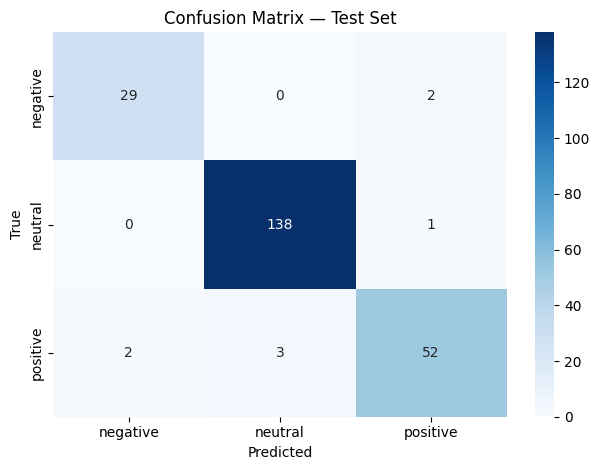

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /content/drive/MyDrive/nlp/final project/distilbert_sentiment/


In [7]:
# CELL D: Evaluate on test set

model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for batch in test_loader:
        out = model(input_ids=batch["input_ids"].to(device),
                    attention_mask=batch["attention_mask"].to(device))
        all_preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
        all_true.extend(batch["labels"].numpy())

print(classification_report(all_true, all_preds, target_names=LABEL_NAMES))

cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title("Confusion Matrix — Test Set")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()


# CELL E: Save fine-tuned model
MODEL_SAVE = "/content/drive/MyDrive/nlp/final project/distilbert_sentiment/"
model.save_pretrained(MODEL_SAVE)
tokenizer.save_pretrained(MODEL_SAVE)
print(f"Model saved to {MODEL_SAVE}")
